In [25]:
from ultralytics import YOLO
import os
import shutil
import matplotlib.pyplot as plt
import cv2
import random
import time
import torch
import onnxruntime as ort
import numpy as np

In [10]:
# 디렉토리 생성

for split in ["train", "valid", "test"]:
    os.makedirs(f'dataset/unity_synthetic_data/{split}/images', exist_ok=True)
    os.makedirs(f'dataset/unity_synthetic_data/{split}/labels', exist_ok=True)

In [5]:
yaml_path = 'dataset/unity_synthetic_data/data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write('train: ../train/images\n')
    f.write('val: ../valid/images\n')
    f.write('test: ../test/images\n')
    f.write('\n')
    f.write(f'nc: 1\n')
    f.write(f"names: ['apple']")

In [12]:
parent_dir = 'dataset/unity_synthetic_data/YOLO_Dataset'

src_image_path = os.path.join(parent_dir, 'images')
src_label_path = os.path.join(parent_dir, 'labels')

src_image_list = [f for f in os.listdir(src_image_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
set_src_image = set(src_image_list)

src_label_list = [f for f in os.listdir(src_label_path) if f.endswith('.txt')]
set_src_label = set(src_label_list)

for image in set_src_image:
    full_image_path = os.path.join(src_image_path, image)
    dest_image_path = f'dataset/unity_synthetic_data/valid/images/{image}'
    # print(f'full_image_path: {full_image_path}')
    # print(f'dest_image_path: {dest_image_path}')
    shutil.copy(full_image_path, dest_image_path)

for label in set_src_label:
    full_label_path = os.path.join(src_label_path, label)
    dest_label_path = f'dataset/unity_synthetic_data/valid/labels/{label}'
    shutil.copy(full_label_path, dest_label_path)

원본 YOLO 라벨 데이터: 0 0.431491 0.401154 0.350000 0.350000


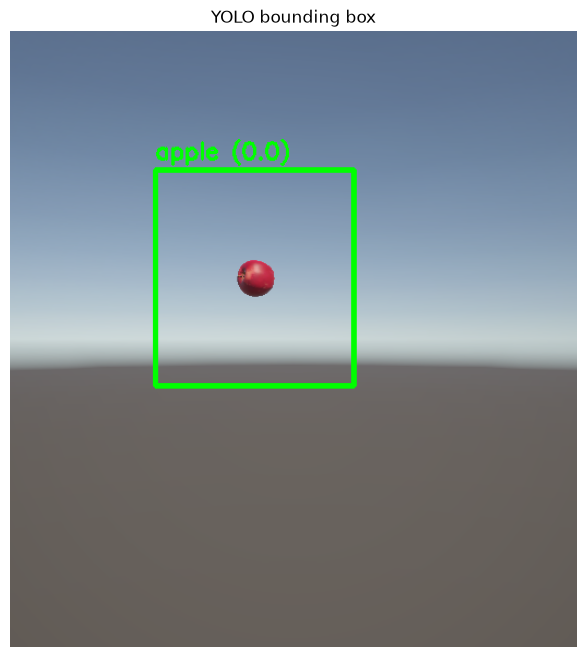

원본 YOLO 라벨 데이터: 0 0.741129 0.427527 0.350000 0.350000


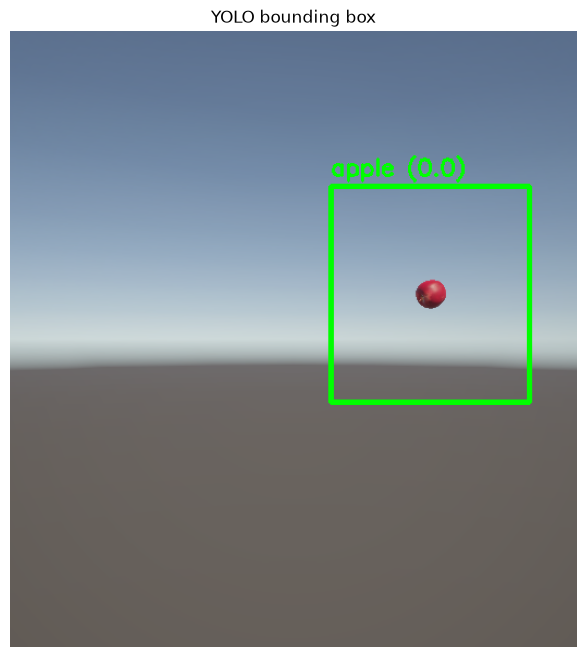

원본 YOLO 라벨 데이터: 0 0.654766 0.826824 0.350000 0.350000


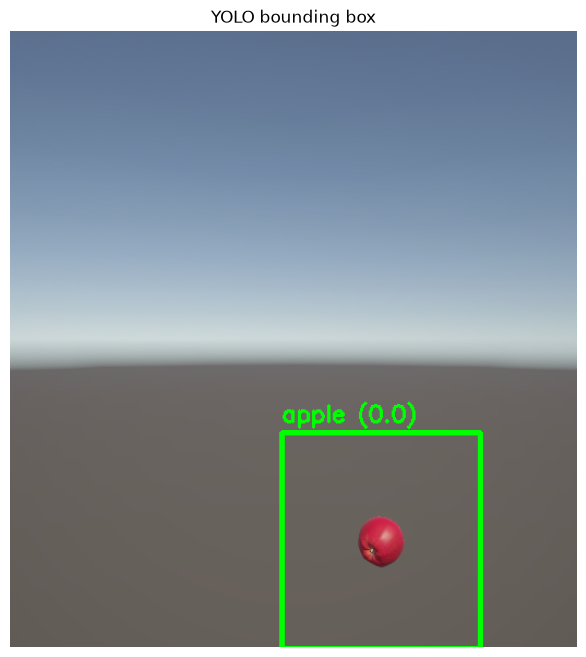

원본 YOLO 라벨 데이터: 0 0.464883 0.708330 0.350000 0.350000


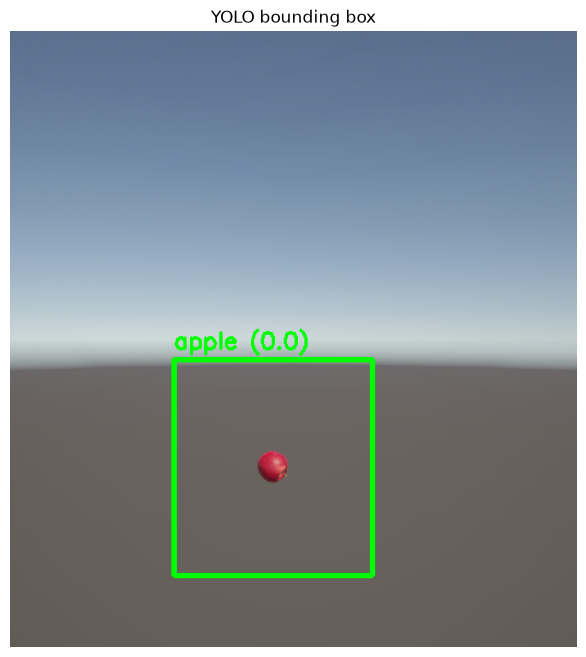

원본 YOLO 라벨 데이터: 0 0.671426 0.223069 0.350000 0.350000


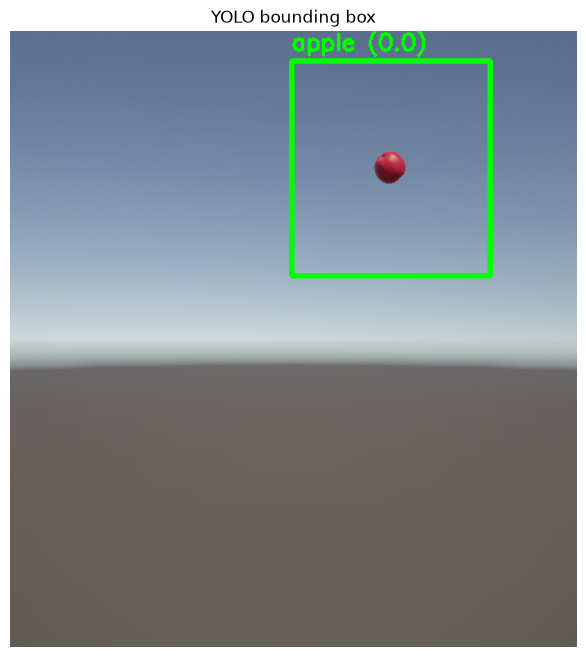

In [19]:
picked_labels = random.sample(src_label_list, k=5)

for label in picked_labels:
    image = label.replace('.txt', '.png')
    image_path = os.path.join('dataset/unity_synthetic_data/train/images', image)
    label_path = os.path.join('dataset/unity_synthetic_data/train/labels', label)

    if not os.path.exists(image_path) or not os.path.exists(label_path):
        print('지정한 경로에 이미지나 라벨이 없습니다.')
    else:
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img_rgb.shape

        with open(label_path, 'r') as f:
            lines = f.readlines()
        print(f'원본 YOLO 라벨 데이터: {lines[0].strip()}')

        for line in lines:
            class_id, x_center, y_center, bbox_w, bbox_h = map(float, line.split())

            pixel_x_center = x_center * w
            pixel_y_center = y_center * h
            pixel_w = bbox_w * w
            pixel_h = bbox_h * h

            xmin = int( pixel_x_center - (pixel_w / 2) )
            ymin = int( pixel_y_center - (pixel_h / 2) )
            xmax = int( pixel_x_center + (pixel_w / 2) )
            ymax = int( pixel_y_center + (pixel_h / 2) )

            cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
            cv2.putText(img_rgb, f'apple ({class_id})', 
                        (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title('YOLO bounding box')
        plt.show()

In [21]:
model = YOLO('yolov8n.pt')

current_dir = os.getcwd()

model.train(
    data=yaml_path, 
    epochs=10, 
    imgsz=640, 
    device='mps', 
    project=os.path.join(current_dir, 'runs'), 
    name='unity_data'
)
print('finished')

New https://pypi.org/project/ultralytics/8.4.138 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/unity_synthetic_data/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=unity_

In [39]:
pt_weight_path = 'runs/unity_data/weights/best.pt'
save_dir = 'runs/unity_data/weights'

model = YOLO(pt_weight_path)

model.export(format='onnx', half=False, dynamic=False, device='mps', project=save_dir)

default_onnx_path = os.path.join(save_dir, 'best.onnx')
fp32_target_path = os.path.join(save_dir, 'best.FP32.onnx')

if (os.path.exists(default_onnx_path)):
    shutil.move(default_onnx_path, fp32_target_path)
    print(f'FP32 변환 및 이름 변경 완료: {fp32_target_path}\n')

model.export(format='onnx', half=True, dynamic=False, device='mps', project=save_dir)
fp16_target_path = os.path.join(save_dir, 'best.FP16.onnx')

if os.path.exists(default_onnx_path):
    shutil.move(default_onnx_path, fp16_target_path)
    print(f'FP16 변환 및 이름 변경 완료: {fp16_target_path}')

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/unity_data/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 0.8s, saved as 'runs/unity_data/weights/best.onnx' (11.7 MB)

Export complete (1.3s)
Results saved to /Users/jeongjaehun/Github/03_object_detection/runs/unity_data/weights/best.onnx
Predict:         yolo predict task=detect model=runs/unity_data/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/unity_data/weights/best.onnx imgsz=640 data=dataset/unity_synthetic_data/data.yaml  
Visualize:       https://netron.app
FP32 변환 및 이름 변경 완료: runs/unity_data/weights/best.FP32.onnx

WARNING

In [48]:
picked_images = random.sample(src_image_list, k=5)

for split in ["best.FP32.onnx", "best.FP16.onnx"]:
    print(f'-------------{split} 추론-------------')
    onnx_weight_path = os.path.join(save_dir, split)
    
    session = ort.InferenceSession(onnx_weight_path, providers=['CoreMLExecutionProvider'])
    
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    target_dtype = np.float16 if split == "best.FP16.onnx" else np.float32
    
    # Warm-up
    for _ in range(5):
        _ = session.run(None, {input_name:np.zeros((1, 3, 640, 640), dtype=target_dtype)})
    
    
    for i, image in enumerate(picked_images):
        start_time = time.time()
        image_path = os.path.join('dataset/unity_synthetic_data/train/images', image)
    
        # 전처리
        img = cv2.imread(image_path)
    
        img_resized = cv2.resize(img, (640, 640))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
        input_tensor = img_rgb.transpose(2, 0, 1).astype(target_dtype) / 255.0
        input_tensor = np.expand_dims(input_tensor, axis=0)
    
        # 순수 추론
        outputs = session.run([output_name], {input_name: input_tensor})
    
        # 후처리
        output = outputs[0]
        predictions = np.squeeze(output)
        # 스코어가 기준치 이상인 박스들만 필터링하는 파이썬 후처리 연산
        boxes = predictions[:4, :]
        scores = np.max(predictions[4:, :], axis=0)
        valid_indices = scores > 0.25
        final_boxes = boxes[:, valid_indices]
    
        latency = (time.time() - start_time) * 1000
        print(f'ONNX Runtime [{i}] 총 추론시간: {latency:.2f} ms')


device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'device: {device}')

pt_model = YOLO(pt_weight_path).to(device)

# Warm-up
for _ in range(5):
    _ = pt_model('dataset/unity_synthetic_data/train/images/apple_0000.png', verbose=False)

for image in picked_images:
    image_path = os.path.join('dataset/unity_synthetic_data/train/images', image)
    start_time = time.time()
    results = pt_model(image_path, verbose=False)
    speed_dict = results[0].speed
    # print(f"proprocess: {speed_dict['preprocess']:2f} ms | \
    # inference: {speed_dict['inference']:2f} ms | postprocess: {speed_dict['postprocess']:2f} ms")
    latency = (time.time() - start_time) * 1000

    total_time = sum(speed_dict.values())
    print(f'latency: {latency:.2f} ms | total: {total_time:.2f} ms')

-------------best.FP32.onnx 추론-------------
ONNX Runtime [0] 총 추론시간: 14.11 ms
ONNX Runtime [1] 총 추론시간: 8.78 ms
ONNX Runtime [2] 총 추론시간: 8.95 ms
ONNX Runtime [3] 총 추론시간: 8.66 ms
ONNX Runtime [4] 총 추론시간: 8.45 ms
-------------best.FP16.onnx 추론-------------
ONNX Runtime [0] 총 추론시간: 27.78 ms
ONNX Runtime [1] 총 추론시간: 26.31 ms
ONNX Runtime [2] 총 추론시간: 23.68 ms
ONNX Runtime [3] 총 추론시간: 25.63 ms
ONNX Runtime [4] 총 추론시간: 23.59 ms
device: mps
latency: 11.67 ms | total: 9.28 ms
latency: 11.86 ms | total: 9.41 ms
latency: 11.58 ms | total: 9.18 ms
latency: 10.19 ms | total: 7.84 ms
latency: 11.62 ms | total: 9.13 ms


In [53]:
class_dict = {0: 'apple', 1: 'banana', 2: 'orange'}
print(class_dict[0])
print(list(class_dict.values()))

apple
['apple', 'banana', 'orange']
